In [1]:
import sys; sys.path.append("../src")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

from data_prep import load_merged, temporal_split
from eval_harness import evaluate
from features import (categorical_columns, fit_categories,
                      apply_categories, add_time_features, feature_list)

df = load_merged("../data/raw")
train, val, test = temporal_split(df)          # test stays sealed until Part E
vocab = fit_categories(train, categorical_columns(train))
train = add_time_features(apply_categories(train, vocab))
val   = add_time_features(apply_categories(val, vocab))
feats = feature_list(train)
y_train, y_val = train["isFraud"], val["isFraud"]


[0]	validation_0-aucpr:0.38547	validation_1-aucpr:0.36799
[100]	validation_0-aucpr:0.68458	validation_1-aucpr:0.55673
[200]	validation_0-aucpr:0.73938	validation_1-aucpr:0.58081
[300]	validation_0-aucpr:0.77375	validation_1-aucpr:0.59256
[400]	validation_0-aucpr:0.80154	validation_1-aucpr:0.59976
[500]	validation_0-aucpr:0.82344	validation_1-aucpr:0.60345
[600]	validation_0-aucpr:0.84299	validation_1-aucpr:0.60567
[700]	validation_0-aucpr:0.85856	validation_1-aucpr:0.60783
[800]	validation_0-aucpr:0.87333	validation_1-aucpr:0.61087
[900]	validation_0-aucpr:0.88437	validation_1-aucpr:0.61256
[1000]	validation_0-aucpr:0.89628	validation_1-aucpr:0.61408
[1025]	validation_0-aucpr:0.89839	validation_1-aucpr:0.61391


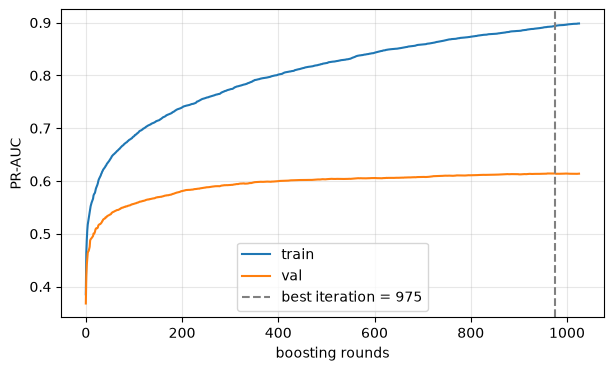

{'name': 'lr=0.05, early-stopped @ 975', 'pr_auc': 0.6144, 'roc_auc': 0.9203, 'threshold': 0.5, 'recall': np.float64(0.4038), 'precision': np.float64(0.8339), 'flagged': 2233, 'missed_fraud': 2749}


In [2]:
model_es = XGBClassifier(
    tree_method="hist", enable_categorical=True, n_jobs=-1, random_state=42,
    n_estimators=2000,            # a budget, not a target — early stopping decides
    learning_rate=0.05,           # smaller steps: less greedy, needs more trees
    eval_metric="aucpr",          # watch PR-AUC, our actual objective
    early_stopping_rounds=50,     # stop after 50 rounds with no val improvement
)
model_es.fit(train[feats], y_train,
             eval_set=[(train[feats], y_train), (val[feats], y_val)],
             verbose=100)

hist = model_es.evals_result()
plt.figure(figsize=(7, 4))
plt.plot(hist["validation_0"]["aucpr"], label="train")
plt.plot(hist["validation_1"]["aucpr"], label="val")
plt.axvline(model_es.best_iteration, ls="--", color="grey",
            label=f"best iteration = {model_es.best_iteration}")
plt.xlabel("boosting rounds"); plt.ylabel("PR-AUC"); plt.legend(); plt.grid(alpha=.3)
plt.show()

proba_es = model_es.predict_proba(val[feats])[:, 1]   # uses best_iteration automatically
print(evaluate(y_val, proba_es, name=f"lr=0.05, early-stopped @ {model_es.best_iteration}"))


In [3]:
base = dict(tree_method="hist", enable_categorical=True, n_jobs=-1, random_state=42,
            n_estimators=2000, learning_rate=0.05, eval_metric="aucpr",
            early_stopping_rounds=50)

configs = {
    "es baseline (depth 6)": {},
    "shallower (depth 4)":   {"max_depth": 4},
    "deeper (depth 8)":      {"max_depth": 8},
    "leaf evidence (mcw 10)":{"min_child_weight": 10},
    "row sampling (0.8)":    {"subsample": 0.8},
    "col sampling (0.8)":    {"colsample_bytree": 0.8},
    "combo: d8+mcw10+samp":  {"max_depth": 8, "min_child_weight": 10,
                              "subsample": 0.8, "colsample_bytree": 0.8},
}

rows = []
for name, extra in configs.items():
    m = XGBClassifier(**{**base, **extra})
    m.fit(train[feats], y_train, eval_set=[(val[feats], y_val)], verbose=False)
    p = m.predict_proba(val[feats])[:, 1]
    r = evaluate(y_val, p, name=name)
    r["best_iter"] = m.best_iteration
    rows.append(r)

pd.DataFrame(rows).set_index("name")[["pr_auc", "roc_auc", "best_iter"]]


,pr_auc,roc_auc,best_iter
name,,,
es baseline (depth 6),0.6144,0.9203,975
shallower (depth 4),0.6077,0.9147,1796
deeper (depth 8),0.6212,0.9241,507
leaf evidence (mcw 10),0.6163,0.9209,899
row sampling (0.8),0.6182,0.9230,701
col sampling (0.8),0.6182,0.9217,974
combo: d8+mcw10+samp,0.6252,0.9245,765


In [ ]:
## Findings (Part A — boosting mechanics)

1. **Default hyperparameters were leaving a lot on the table**: lr=0.05 + early stopping
   (975 rounds) lifted val PR-AUC 0.577 → 0.614; adding regularization
   (depth 8, min_child_weight 10, row/col subsampling 0.8) → **0.625**.
   Tuning gained +0.048 — more than the entire feature-engineering chapter (+0.020).
2. **Overfitting, visualized**: train PR-AUC 0.90 and climbing vs val 0.61 plateaued —
   the gap is memorization capacity; early stopping is the refusal to fund it.
3. **Capacity↔rounds inverse confirmed**: depth 4 → 1,796 rounds; depth 8 → 507.
   Early stopping auto-balances complexity-per-tree against number of trees.
4. Caveat: 7 configs evaluated on val, max selected — 0.625 is mildly
   selection-flattered. Unbiased measurement deferred to the sealed test set (Part E).
